# 9장 실습 — 데이터 혼합비와 미세조정

3장이 본 것을 떠올린다. 시뮬레이터(명목 조건)의 시연을 아무리 늘려도 **배포 조건의 실패가 줄지 않았다.** 배포의 바닥은 데이터의 양이 아니라 데이터가 온 곳의 문제였다.

이 노트북은 **배포 조건에서 모은 시연** — 이 책의 말로 **현장 데이터** — 을 소량 섞는다. 현장 데이터는 비싸다. 그래서 질문은 둘이다.

1. **얼마나 섞는가** — 미니배치에서 현장 데이터가 차지하는 비율을 0에서 1까지 훑는다
2. **어떻게 섞는가** — 처음부터 섞어 학습하는 것(공동 학습)과, 시뮬레이터 데이터로 학습한 정책을 현장 데이터로 이어 학습하는 것(미세조정). 미세조정은 다시 둘로 나뉜다 — 현장 데이터**만**으로 이어 학습하는 것(바꿔 쓰기)과, 시뮬레이터 데이터를 함께 되풀이하는 것(더해 쓰기)

그리고 현장 시연을 몇 판 모아야 하는지를 4판에서 32판까지 잰다.

끝에서 `data/field_v1.npz` 와 `policy/mix_v1.pt` 를 남긴다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


## 현장 데이터

배포 조건의 셀 — 관측 편향, 제어 지연 한 주기, 마찰 0.8 — 에서 2장의 잡음 주입 경로로 시연을 모은다. 라벨은 **참 상태를 보는 전문가**의 명령이고, 기록되는 관측은 **편향이 섞인 관측**이다. 실기로 옮기면 「현장에서 사람이 시연하고, 로봇의 센서가 기록한 것」이다. 전문가는 편향을 보지 않으므로, 이 데이터에는 **편향된 관측에서 무엇을 해야 하는지**가 들어 있다.

In [8]:
K_MAIN = 16
t0 = time.time()
XF, YF, LF = dart_eps(K_MAIN, seed=3, cond="배포")
print(f"현장 시연 {K_MAIN}판 · {len(XF):,} 스텝  "
      f"({time.time() - t0:.0f}s)")
print(f"시뮬레이터 시연 128판 · {len(XS):,} 스텝")
share = len(XF) / (len(XF) + len(XS))
print(f"현장 데이터의 몫 (스텝 기준) {share:.1%}")

현장 시연 16판 · 721 스텝  (0s)
시뮬레이터 시연 128판 · 5,792 스텝
현장 데이터의 몫 (스텝 기준) 11.1%


In [9]:
def train_mix(XA, YA, XB=None, YB=None, r=0., steps=4000, seed=0,
              net=None, lr=1e-3, bs=512):
    """미니배치의 r 만큼은 B(현장), 나머지는 A(시뮬레이터)에서"""
    torch.manual_seed(seed)
    net = net or AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    g = torch.Generator().manual_seed(seed)
    A = (torch.from_numpy(XA), torch.from_numpy(YA))
    B = None if XB is None else (torch.from_numpy(XB),
                                 torch.from_numpy(YB))
    nb = int(round(bs * r)) if B is not None else 0
    for _ in range(steps):
        xs, ys = [], []
        for D, m in ((A, bs - nb), (B, nb)):
            if m:
                j = torch.randint(0, len(D[0]), (m,), generator=g)
                xs.append(D[0][j])
                ys.append(D[1][j])
        x, y = torch.cat(xs), torch.cat(ys)
        loss = ((net.pi(x) - y) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


SN, FN = nz(XS), nz(XF)
SEEDS = (0, 1, 2)
EV = dict(n=100, reps=2)
LOG, SC, NETS = [], {}, {}


def evaluate(name, make):
    for s in SEEDS:
        net = make(s)
        NETS[(name, s)] = net
        for c in COND:
            rows = rollout(pol(net), c, tag=s, ver=f"mix-{name}",
                           **EV)
            LOG.extend(rows)
            SC.setdefault((name, c), []).append(rate(rows))

## 혼합비

미니배치 512개 가운데 현장 데이터에서 뽑는 비율 r 을 0, 0.1, 0.25, 0.5, 1로 바꾼다. r=0은 시뮬레이터만, r=1은 현장만이다. 현장 데이터는 전체 스텝의 11% 남짓이므로, r=0.1이 대략 「그냥 합쳐서 섞은 것」에 해당한다.

In [10]:
RATIO = [0., .1, .25, .5, 1.]
t0 = time.time()
for r in RATIO:
    make = lambda s, r=r: train_mix(SN, YS, FN, YF, r=r, seed=s)
    evaluate(f"r={r:g}", make)
    print(f"  r={r:g} 끝  ({time.time() - t0:.0f}s)", flush=True)


def show(keys, label, w=18):
    print(pad(label, w) + pad("명목", 20, True)
          + pad("배포", 20, True))
    for k in keys:
        cells = [f"{np.mean(SC[(k, c)]):.3f} "
                 f"[{min(SC[(k, c)]):.2f}, {max(SC[(k, c)]):.2f}]"
                 for c in COND]
        print(pad(k, w) + "".join(pad(x, 20, True) for x in cells))


print()
show([f"r={r:g}" for r in RATIO], "혼합비")

  r=0 끝  (41s)


  r=0.1 끝  (82s)


  r=0.25 끝  (123s)


  r=0.5 끝  (165s)


  r=1 끝  (204s)



혼합비                            명목                배포
r=0                 1.000 [1.00, 1.00]  0.936 [0.89, 0.97]
r=0.1               1.000 [1.00, 1.00]  0.979 [0.94, 1.00]
r=0.25              1.000 [1.00, 1.00]  0.995 [0.99, 1.00]
r=0.5               0.997 [0.99, 1.00]  0.988 [0.98, 1.00]
r=1                 0.671 [0.52, 0.80]  0.997 [0.99, 1.00]


## 미세조정 — 바꿔 쓰기와 더해 쓰기

시뮬레이터 데이터로 4,000 스텝 학습한 정책을 1,000 스텝 이어 학습한다. 두 방식을 맞세운다.

- **바꿔 쓰기** — 이어 학습에서 현장 데이터**만** 쓴다
- **더해 쓰기** — 이어 학습에서도 시뮬레이터 데이터를 절반 섞는다 (r=0.5)

4권 17장은 개입 데이터를 두고 「더해서 쓰고 바꿔서 쓰지 않는다」고 결론지었다. 현장 데이터에서도 같은 결론이 나오는지 본다.

In [11]:
def finetune(s, r):
    base = train_mix(SN, YS, seed=s)
    return train_mix(SN, YS, FN, YF, r=r, steps=1000, seed=s + 100,
                     net=base)


t0 = time.time()
evaluate("바꿔 쓰기", lambda s: finetune(s, 1.))
evaluate("더해 쓰기", lambda s: finetune(s, .5))
print(f"({time.time() - t0:.0f}s)\n")
show(["r=0", "r=1", "바꿔 쓰기", "더해 쓰기", "r=0.25"], "방식")

(89s)

방식                              명목                배포
r=0                 1.000 [1.00, 1.00]  0.936 [0.89, 0.97]
r=1                 0.671 [0.52, 0.80]  0.997 [0.99, 1.00]
바꿔 쓰기           0.959 [0.88, 1.00]  1.000 [1.00, 1.00]
더해 쓰기           1.000 [1.00, 1.00]  0.999 [1.00, 1.00]
r=0.25              1.000 [1.00, 1.00]  0.995 [0.99, 1.00]


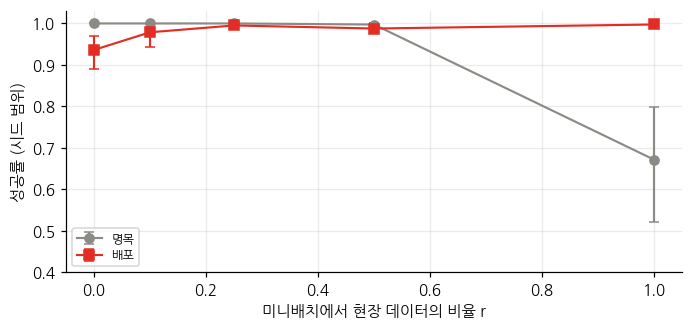

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 3.1))
for c, col, mk in (("명목", GREY, "o"), ("배포", RED, "s")):
    m = np.array([np.mean(SC[(f"r={r:g}", c)]) for r in RATIO])
    lo = m - np.array([min(SC[(f"r={r:g}", c)]) for r in RATIO])
    hi = np.array([max(SC[(f"r={r:g}", c)]) for r in RATIO]) - m
    ax.errorbar(RATIO, m, yerr=[lo, hi], color=col, marker=mk,
                capsize=3, lw=1.4, label=c)
ax.set_xlabel("미니배치에서 현장 데이터의 비율 r")
ax.set_ylabel("성공률 (시드 범위)")
ax.set_ylim(.4, 1.03)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## 현장 시연은 몇 판이면 되는가

r=0.25로 고정하고 현장 시연의 수를 4, 8, 16, 32판으로 바꾼다. 16판은 앞에서 잰 것을 그대로 쓴다.

In [13]:
KS = [4, 8, 16, 32]
t0 = time.time()
for k in KS:
    if k == K_MAIN:
        SC[("K=16", "명목")] = SC[("r=0.25", "명목")]
        SC[("K=16", "배포")] = SC[("r=0.25", "배포")]
        continue
    Xk, Yk, _ = dart_eps(k, seed=3, cond="배포")
    Fk = nz(Xk)
    evaluate(f"K={k}", lambda s, Fk=Fk, Yk=Yk:
             train_mix(SN, YS, Fk, Yk, r=.25, seed=s))
    print(f"  K={k} 끝  ({time.time() - t0:.0f}s)", flush=True)
print()
show(["r=0"] + [f"K={k}" for k in KS], "현장 시연 수")

  K=4 끝  (42s)


  K=8 끝  (83s)


  K=32 끝  (126s)



현장 시연 수                      명목                배포
r=0                 1.000 [1.00, 1.00]  0.936 [0.89, 0.97]
K=4                 1.000 [1.00, 1.00]  0.936 [0.89, 0.99]
K=8                 1.000 [1.00, 1.00]  0.954 [0.93, 0.99]
K=16                1.000 [1.00, 1.00]  0.995 [0.99, 1.00]
K=32                1.000 [1.00, 1.00]  1.000 [1.00, 1.00]


## 혼합 정책을 남긴다

규칙을 코드로 적는다. **명목과 배포 두 조건의 평균 가운데 낮은 쪽이 가장 높은 방식**을 고른다. 한 조건만 잘하는 방식은 뽑히지 않는다.

In [14]:
names = [f"r={r:g}" for r in RATIO] + ["바꿔 쓰기", "더해 쓰기"]
worst = {k: min(np.mean(SC[(k, c)]) for c in COND) for k in names}
pick = max(names, key=worst.get)
os.makedirs("policy", exist_ok=True)
os.makedirs("data", exist_ok=True)
torch.save(NETS[(pick, 0)], "policy/mix_v1.pt")
np.savez_compressed("data/field_v1.npz", X=XF, Y=YF, lengths=LF)
MIX = {"pick": pick, "rule": "min(명목, 배포) 최대",
       "field_demos": K_MAIN, "field_steps": int(len(XF)),
       "scores": {k: {c: round(float(np.mean(SC[(k, c)])), 3)
                      for c in COND} for k in names}}
with open("policy/mix_v1.json", "w") as f:
    json.dump(MIX, f, ensure_ascii=False, indent=1)
save_log("report/ch09_log.csv", LOG)
for k in names:
    print(pad(k, 12) + f"두 조건 중 낮은 쪽 {worst[k]:.3f}")
print(f"\n고른 방식: {pick}")
print()
print("남긴 산출물")
print(f"  data/field_v1.npz     현장 {K_MAIN}판 · {len(XF):,} 스텝")
print("  policy/mix_v1.pt      고른 방식의 정책 (시드 0)")
print("  policy/mix_v1.json    규칙과 방식별 성적")
print(f"  report/ch09_log.csv   판별 로그 {len(LOG):,}줄")

r=0         두 조건 중 낮은 쪽 0.936
r=0.1       두 조건 중 낮은 쪽 0.979
r=0.25      두 조건 중 낮은 쪽 0.995
r=0.5       두 조건 중 낮은 쪽 0.988
r=1         두 조건 중 낮은 쪽 0.671
바꿔 쓰기   두 조건 중 낮은 쪽 0.959
더해 쓰기   두 조건 중 낮은 쪽 0.999

고른 방식: 더해 쓰기

남긴 산출물
  data/field_v1.npz     현장 16판 · 721 스텝
  policy/mix_v1.pt      고른 방식의 정책 (시드 0)
  policy/mix_v1.json    규칙과 방식별 성적
  report/ch09_log.csv   판별 로그 22,454줄


## 정리

**현장 데이터는 조금이면 되고, 섞는 비율이 중요하다.** 스텝의 11%인 현장 시연 16판을 미니배치의 25%로 섞으면 명목 1.000, 배포 0.995다. 현장만 쓰면 명목이 0.671로 무너진다.

**바꿔 쓰지 말고 더해 쓴다.** 시뮬레이터 정책을 현장 데이터만으로 이어 학습하면 명목이 0.959로 떨어진다. 시뮬레이터 데이터를 함께 되풀이하면 두 조건 모두 1.000 근처다.

**배포의 바닥은 데이터가 온 곳이 정한다.** 시뮬레이터 시연 825판이 못 내린 바닥을 현장 시연 16판이 내렸다.

**3부가 넘기는 정책은 셋이다.** 기준선 둘(`policy/bc_v1.pt`, `policy/rl_v1.pt`)과 혼합 정책(`policy/mix_v1.pt`)이다. 4부는 현장 데이터가 **없을 때** 같은 바닥을 어떻게 내릴 수 있는지 — 갭을 재고, 시뮬레이터를 현장에 맞추고, 랜덤화로 버티는 법을 — 다룬다.